In [2]:
#------------------------------------------------------- Kasra Attar Kashani-------------------------------
#-------------------------------------------------------  DIP - CHW4 -------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from skimage import io, color, img_as_float
from skimage.restoration import wiener, richardson_lucy
from skimage.metrics import peak_signal_noise_ratio as psnr
import scipy.signal
import scipy.fftpack

# for Task 4
import torch
import torch.nn as torch_nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

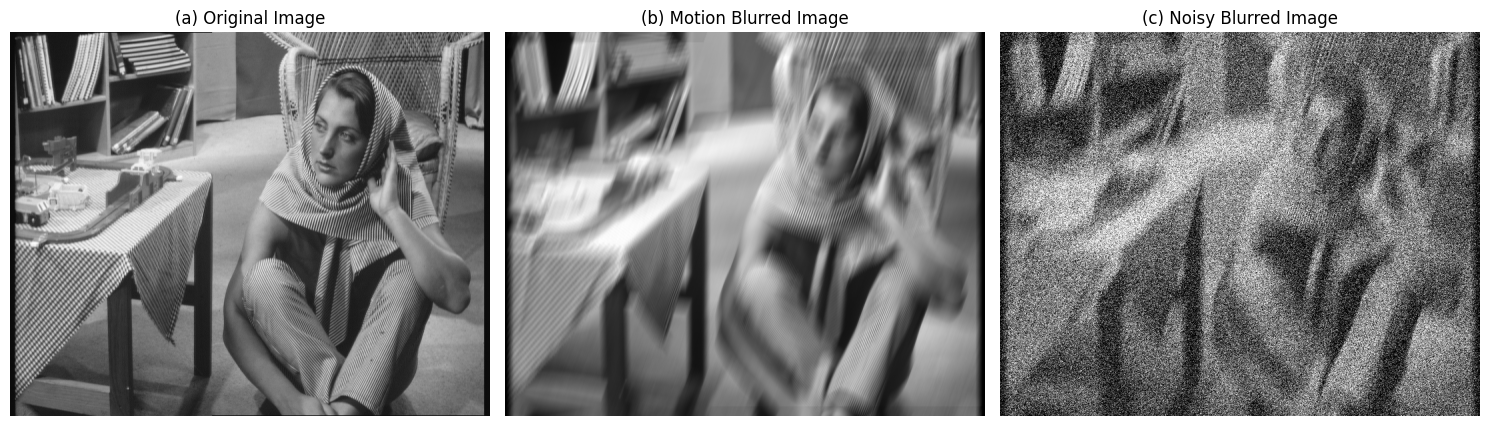

In [4]:
#------------------------------------------------------- Kasra Attar Kashani-------------------------------
#-------------------------------------------------------  DIP - CHW4 -------------------------------------------------
#------------------------------------------------------- TASK 1 ------------------------------------------------------
#-------------------------------------------------------- STEP 1 & STEP 2 --------------------------------------------
# Step 1: Load Image and apply linear motion blur
# Load and convert to grayscale. normalized [0, 1]
original_img = img_as_float(color.rgb2gray(io.imread('barbara_color.png')))

# Generate custom 31x31 PSF for 70-degree linear motion blur
kernel_size = 31
psf = np.zeros((kernel_size, kernel_size))
center = kernel_size // 2
angle_rad = np.deg2rad(70)

# Draw line
for t in range(-kernel_size // 2, kernel_size // 2 + 1):
    x = int(round(center + t * np.cos(angle_rad)))
    y = int(round(center - t * np.sin(angle_rad)))
    if 0 <= x < kernel_size and 0 <= y < kernel_size:
        psf[y, x] = 1.0

psf /= psf.sum() # Normalize kernel

# motion blur
blurred_img = scipy.signal.convolve2d(original_img, psf, mode='same', boundary='symm')

# Step 2: Gaussian noise
variance = 0.05
sigma = np.sqrt(variance)
noise = np.random.normal(0, sigma, original_img.shape)

# Add noise [0, 1] range
degraded_img = np.clip(blurred_img + noise, 0.0, 1.0)

# Results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(original_img, cmap='gray')
ax[0].set_title('(a) Original Image')
ax[0].axis('off')

ax[1].imshow(blurred_img, cmap='gray')
ax[1].set_title('(b) Motion Blurred Image')
ax[1].axis('off')

ax[2].imshow(degraded_img, cmap='gray')
ax[2].set_title('(c) Noisy Blurred Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Optimal Wiener Balance: 20 (PSNR: 20.73 dB)
Optimal RL Iterations: 5 (PSNR: 16.60 dB)


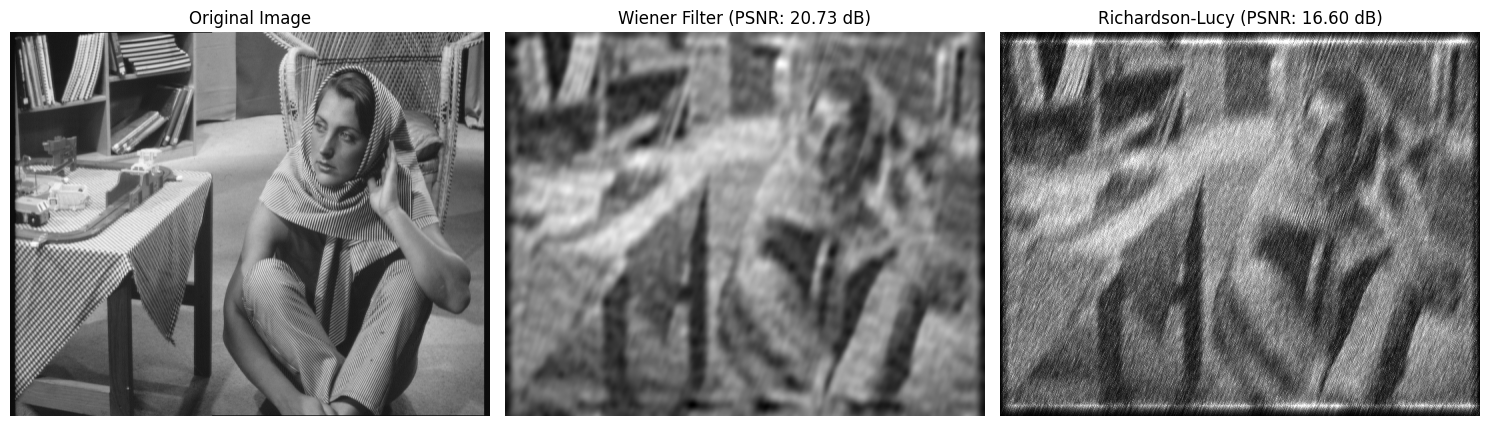

In [5]:
#------------------------------------------------------- Kasra Attar Kashani-------------------------------
#-------------------------------------------------------  DIP - CHW4 -------------------------------------------------
#------------------------------------------------------- TASK 2 ------------------------------------------------------
#-------------------------------------------------------- STEP 1 & STEP 2 & STEP 3------------------------------------
# Step 1: Wiener Filtering optimization
balance_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 20]
best_wiener_psnr = 0
best_wiener_img = None
best_balance = 0

for b in balance_values:
    restored_w = wiener(degraded_img, psf, balance=b, clip=False)
    current_psnr = psnr(original_img, np.clip(restored_w, 0, 1), data_range=1.0)
    if current_psnr > best_wiener_psnr:
        best_wiener_psnr = current_psnr
        best_wiener_img = np.clip(restored_w, 0, 1)
        best_balance = b

print(f"Optimal Wiener Balance: {best_balance} (PSNR: {best_wiener_psnr:.2f} dB)")

# Step 2: Richardson optimization
iterations = [5, 15, 30, 50]
best_rl_psnr = 0
best_rl_img = None
best_iter = 0

for it in iterations:
    # RL can amplify noise , so we test it
    restored_rl = richardson_lucy(degraded_img, psf, num_iter=it, clip=False)
    current_psnr = psnr(original_img, np.clip(restored_rl, 0, 1), data_range=1.0)
    if current_psnr > best_rl_psnr:
        best_rl_psnr = current_psnr
        best_rl_img = np.clip(restored_rl, 0, 1)
        best_iter = it

print(f"Optimal RL Iterations: {best_iter} (PSNR: {best_rl_psnr:.2f} dB)")

# Step 3: Display
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(original_img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(best_wiener_img, cmap='gray')
ax[1].set_title(f'Wiener Filter (PSNR: {best_wiener_psnr:.2f} dB)')
ax[1].axis('off')

ax[2].imshow(best_rl_img, cmap='gray')
ax[2].set_title(f'Richardson-Lucy (PSNR: {best_rl_psnr:.2f} dB)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Optimal Gamma for CLS: 31.6228 (PSNR: 14.26 dB)


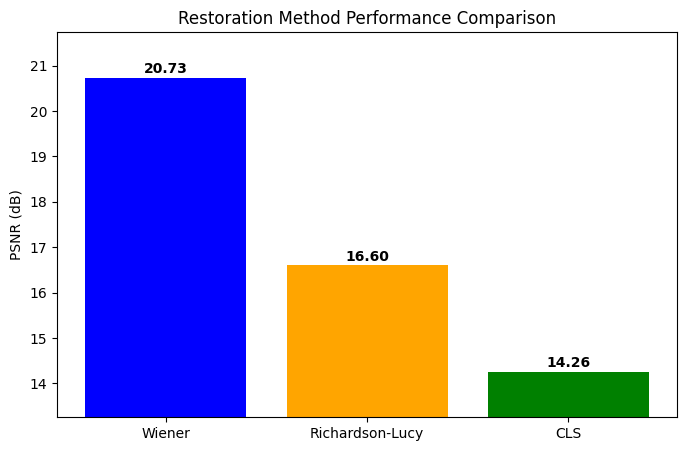

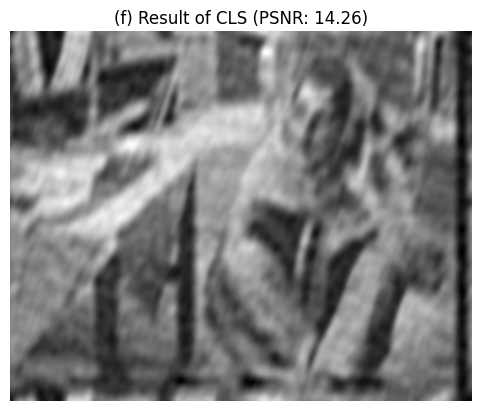

In [6]:
#------------------------------------------------------- Kasra Attar Kashani-------------------------------
#-------------------------------------------------------  DIP - CHW4 -------------------------------------------------
#------------------------------------------------------- TASK 3 ------------------------------------------------------
#-------------------------------------------------------- STEP 1 & STEP 2 & STEP 3------------------------------------
# Step 1: CLS Restoration
def cls_filter(degraded, psf, gamma):
    img_shape = degraded.shape
    
    # Laplac operator
    laplacian = np.array([[0, -1, 0],
                          [-1, 4, -1],
                          [0, -1, 0]])
    
    # FFTs
    H = scipy.fftpack.fft2(psf, shape=img_shape)
    P = scipy.fftpack.fft2(laplacian, shape=img_shape)
    G = scipy.fftpack.fft2(degraded, shape=img_shape)
    
    # CLS frequency domain transfer function
    H_conj = np.conj(H)
    H_mag_sq = np.abs(H)**2
    P_mag_sq = np.abs(P)**2
    
    F_hat = (H_conj * G) / (H_mag_sq + gamma * P_mag_sq)
    
    # Inverse FFT 
    restored = np.real(scipy.fftpack.ifft2(F_hat))
    return np.clip(restored, 0, 1)

# Search for optimal gamma parameter
gamma_values = np.logspace(-3, 1.5, 50) # sweep from 0.001 to ~31
best_cls_psnr = 0
best_cls_img = None
best_gamma = 0

for gamma in gamma_values:
    restored_cls = cls_filter(degraded_img, psf, gamma)
    current_psnr = psnr(original_img, restored_cls, data_range=1.0)
    if current_psnr > best_cls_psnr:
        best_cls_psnr = current_psnr
        best_cls_img = restored_cls
        best_gamma = gamma

print(f"Optimal Gamma for CLS: {best_gamma:.4f} (PSNR: {best_cls_psnr:.2f} dB)")

# Step 2 & 3: Comparison and Chart
labels = ['Wiener', 'Richardson-Lucy', 'CLS']
psnr_scores = [best_wiener_psnr, best_rl_psnr, best_cls_psnr]

plt.figure(figsize=(8, 5))
plt.bar(labels, psnr_scores, color=['blue', 'orange', 'green'])
plt.ylabel('PSNR (dB)')
plt.title('Restoration Method Performance Comparison')
plt.ylim([min(psnr_scores) - 1, max(psnr_scores) + 1])
for i, v in enumerate(psnr_scores):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# Result
plt.imshow(best_cls_img, cmap='gray')
plt.title(f'(f) Result of CLS (PSNR: {best_cls_psnr:.2f})')
plt.axis('off')
plt.show()

Training Custom U-Net...
Epoch [1/10], Loss: 0.0374
Epoch [2/10], Loss: 0.0336
Epoch [3/10], Loss: 0.0326
Epoch [4/10], Loss: 0.0320
Epoch [5/10], Loss: 0.0312
Epoch [6/10], Loss: 0.0307
Epoch [7/10], Loss: 0.0305
Epoch [8/10], Loss: 0.0304
Epoch [9/10], Loss: 0.0299
Epoch [10/10], Loss: 0.0297


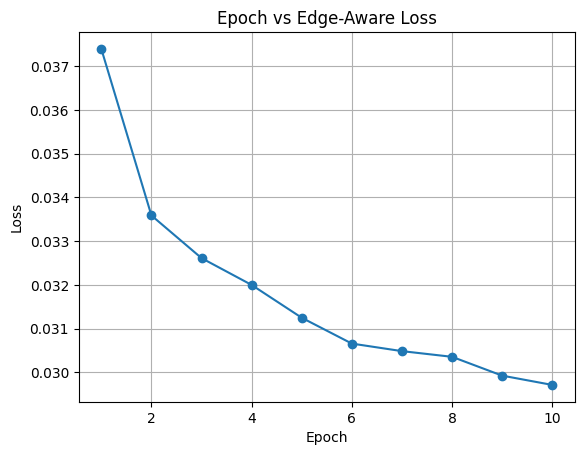

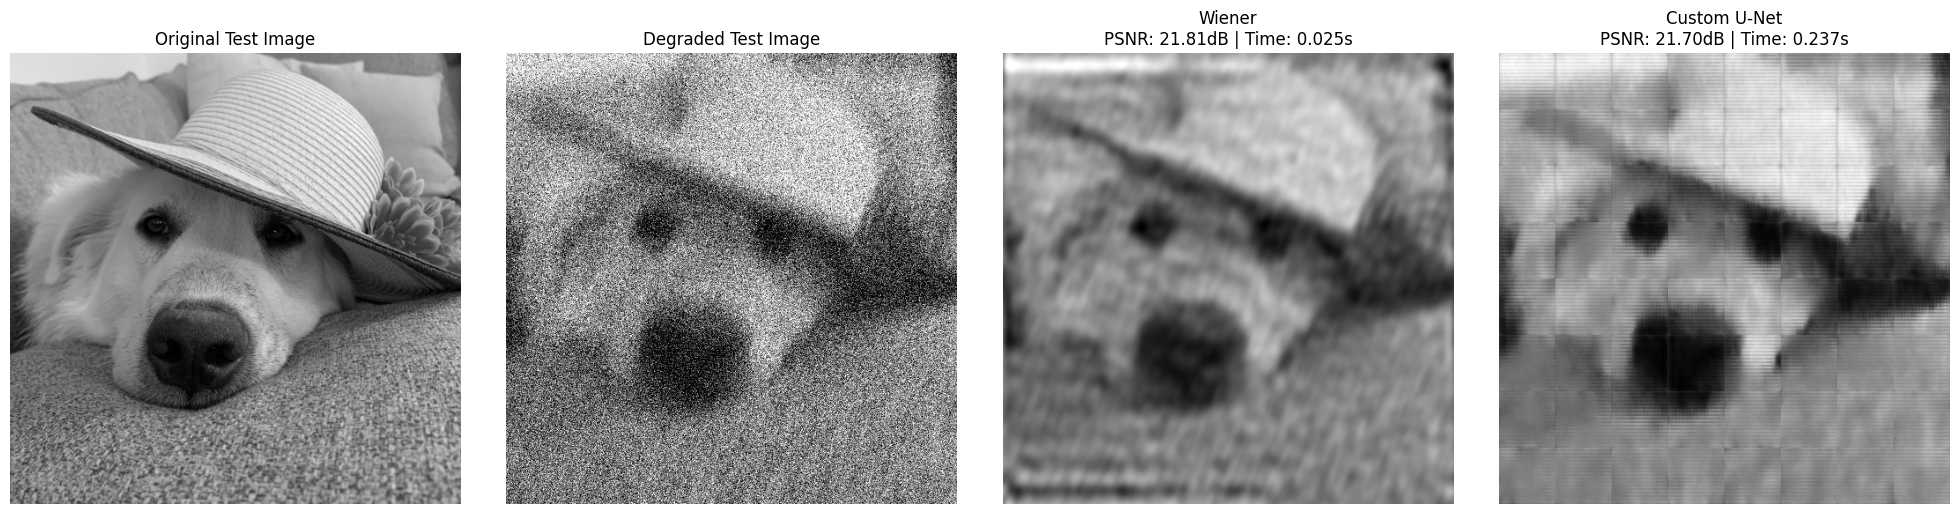

In [7]:
#------------------------------------------------------- Kasra Attar Kashani-------------------------------
#-------------------------------------------------------  DIP - CHW4 -------------------------------------------------
#------------------------------------------------------- TASK 4 ------------------------------------------------------
#-------------------------------------------------------- STEP 1 & STEP 2 & STEP 3 & STEP 4 & STEP 5------------------
# Task 4 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Step 1: U-Net Architecture 
class CustomUNet(torch_nn.Module):
    def __init__(self):
        super(CustomUNet, self).__init__()
        
        # Encoder 
        self.enc1 = torch_nn.Sequential(
            torch_nn.Conv2d(1, 16, kernel_size=5, padding=2),
            torch_nn.BatchNorm2d(16),
            torch_nn.ReLU(inplace=True)
        )
        self.enc2 = torch_nn.Sequential(
            torch_nn.Conv2d(16, 32, kernel_size=5, padding=2),
            torch_nn.BatchNorm2d(32),
            torch_nn.ReLU(inplace=True)
        )
        
        # Bottleneck 
        self.bottleneck = torch_nn.Sequential(
            torch_nn.Conv2d(32, 64, kernel_size=5, padding=2),
            torch_nn.BatchNorm2d(64),
            torch_nn.ReLU(inplace=True)
        )
        
        # DSP Skip 
        self.skip2_reduce = torch_nn.Conv2d(32, 16, kernel_size=1)
        self.skip1_reduce = torch_nn.Conv2d(16, 8, kernel_size=1)
        
        # Decoder 
        self.up1 = torch_nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        # Input : 32 + 16 (from reduced skip2) = 48
        self.dec1 = torch_nn.Sequential(
            torch_nn.Conv2d(48, 32, kernel_size=5, padding=2),
            torch_nn.BatchNorm2d(32),
            torch_nn.ReLU(inplace=True)
        )
        
        self.up2 = torch_nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        # Input : 16 + 8 (from reduced skip1) = 24
        self.dec2 = torch_nn.Sequential(
            torch_nn.Conv2d(24, 16, kernel_size=5, padding=2),
            torch_nn.BatchNorm2d(16),
            torch_nn.ReLU(inplace=True)
        )
        
        # Final Output Layer
        self.final_conv = torch_nn.Conv2d(16, 1, kernel_size=1)
        
    def forward(self, x):
        # Downsampling
        e1 = self.enc1(x)
        p1 = F.max_pool2d(e1, 2)
        
        e2 = self.enc2(p1)
        p2 = F.max_pool2d(e2, 2)
        
        # Bottleneck
        b = self.bottleneck(p2)
        
        # Upsampling 1
        d1 = self.up1(b)
        s2 = self.skip2_reduce(e2) 
        d1_cat = torch.cat((d1, s2), dim=1)
        d1_out = self.dec1(d1_cat)
        
        # Upsampling 2
        d2 = self.up2(d1_out)
        s1 = self.skip1_reduce(e1) 
        d2_cat = torch.cat((d2, s1), dim=1)
        d2_out = self.dec2(d2_cat)
        
        return torch.sigmoid(self.final_conv(d2_out))

#  Step 2: Edge Loss Function 
class EdgeAwareLoss(torch_nn.Module):
    def __init__(self, lambda_edge=0.10):
        super(EdgeAwareLoss, self).__init__()
        self.mse = torch_nn.MSELoss()
        self.lambda_edge = lambda_edge
        
        # Sobel kernels
        sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)
        
    def compute_edges(self, x):
        edge_x = F.conv2d(x, self.sobel_x, padding=1)
        edge_y = F.conv2d(x, self.sobel_y, padding=1)
        return torch.abs(edge_x) + torch.abs(edge_y)

    def forward(self, pred, target):
        mse_base = self.mse(pred, target)
        pred_edges = self.compute_edges(pred)
        target_edges = self.compute_edges(target)
        mse_edges = self.mse(pred_edges, target_edges)
        return mse_base + self.lambda_edge * mse_edges

# Step 3: Training Pipeline and Data Augmentation 
def prepare_dataset():
    images = ['barbara_color.png', 'chelsea.png', 'lighthouse.png', 'monarch_color.png']
    patch_size = 64
    x_data, y_data = [], []
    
    for img_name in images:
        # Load and add artifacts 
        clean = img_as_float(color.rgb2gray(io.imread(img_name)))
        blur = scipy.signal.convolve2d(clean, psf, mode='same', boundary='symm')
        noisy = np.clip(blur + np.random.normal(0, sigma, blur.shape), 0, 1)
        
        h, w = clean.shape
        # Extract 64x64 
        for i in range(0, h - patch_size + 1, patch_size):
            for j in range(0, w - patch_size + 1, patch_size):
                clean_patch = clean[i:i+patch_size, j:j+patch_size]
                noisy_patch = noisy[i:i+patch_size, j:j+patch_size]
                
                # Augmentation 
                augments = [
                    (clean_patch, noisy_patch),
                    (np.fliplr(clean_patch), np.fliplr(noisy_patch)),
                    (np.flipud(clean_patch), np.flipud(noisy_patch)),
                    (np.rot90(clean_patch), np.rot90(noisy_patch))
                ]
                
                for cp, np_patch in augments:
                    x_data.append(np_patch.copy())
                    y_data.append(cp.copy())
                    
    # Convert to DataLoader
    x_tensor = torch.tensor(np.array(x_data), dtype=torch.float32).unsqueeze(1)
    y_tensor = torch.tensor(np.array(y_data), dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(x_tensor, y_tensor)
    return DataLoader(dataset, batch_size=32, shuffle=True)

dataloader = prepare_dataset()
model = CustomUNet().to(device)
criterion = EdgeAwareLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training Loop
epochs = 10
epoch_losses = []

print("Training Custom U-Net...")
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# Step 4 & 5: Analysis 
# Plot Epoch vs Loss
plt.figure()
plt.plot(range(1, epochs + 1), epoch_losses, marker='o')
plt.title('Epoch vs Edge-Aware Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

# Generalization on lilly
test_clean = img_as_float(color.rgb2gray(io.imread('lilly.jpg')))
test_blur = scipy.signal.convolve2d(test_clean, psf, mode='same', boundary='symm')
test_degraded = np.clip(test_blur + np.random.normal(0, sigma, test_clean.shape), 0, 1)

# dimensions divisible by 64 for patching
h, w = test_clean.shape
pad_h = (64 - h % 64) % 64
pad_w = (64 - w % 64) % 64
test_degraded_pad = np.pad(test_degraded, ((0, pad_h), (0, pad_w)), mode='reflect')
unet_restored_pad = np.zeros_like(test_degraded_pad)

# UNet Inference Time
start_time = time.time()
model.eval()
with torch.no_grad():
    for i in range(0, h + pad_h, 64):
        for j in range(0, w + pad_w, 64):
            patch = test_degraded_pad[i:i+64, j:j+64]
            patch_t = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            out_patch = model(patch_t).squeeze().cpu().numpy()
            unet_restored_pad[i:i+64, j:j+64] = out_patch
unet_time = time.time() - start_time

unet_restored = unet_restored_pad[:h, :w] # Crop back to original size
unet_psnr = psnr(test_clean, unet_restored, data_range=1.0)

# Wiener Inference Time
start_time = time.time()
wiener_restored = wiener(test_degraded, psf, balance=best_balance, clip=False)
wiener_restored = np.clip(wiener_restored, 0, 1)
wiener_time = time.time() - start_time
wiener_psnr = psnr(test_clean, wiener_restored, data_range=1.0)

# Comparison 
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(test_clean, cmap='gray')
ax[0].set_title('Original Test Image')
ax[0].axis('off')

ax[1].imshow(test_degraded, cmap='gray')
ax[1].set_title('Degraded Test Image')
ax[1].axis('off')

ax[2].imshow(wiener_restored, cmap='gray')
ax[2].set_title(f'Wiener\nPSNR: {wiener_psnr:.2f}dB | Time: {wiener_time:.3f}s')
ax[2].axis('off')

ax[3].imshow(unet_restored, cmap='gray')
ax[3].set_title(f'Custom U-Net\nPSNR: {unet_psnr:.2f}dB | Time: {unet_time:.3f}s')
ax[3].axis('off')

plt.tight_layout()
plt.show()